# Final Notebook Conclusion

## Objective Achieved

An XGBoost forecasting model was successfully developed and evaluated for hourly NYC taxi demand prediction using feature-engineered historical demand data.

The primary objective of this notebook was to determine whether a machine learning approach could effectively learn demand patterns from engineered temporal and historical features and provide accurate future demand forecasts.

---

## Work Performed

The following workflow was completed throughout this notebook:

### Data Preparation

- Loaded the feature-engineered demand dataset.
- Verified dataset structure and quality.
- Checked for missing values.
- Sorted observations chronologically to preserve temporal order.

### Feature Preparation

- Defined forecasting target (`demand`).
- Selected engineered predictor variables.
- Encoded categorical features into machine-learning-compatible numerical values.
- Verified that all features were suitable for XGBoost training.

### Dataset Splitting

A chronological split strategy was implemented to prevent data leakage:

- Training Set → 70%
- Validation Set → 15%
- Test Set → 15%

This approach ensured that the model learned only from past observations and was evaluated on future unseen data.

### Model Development

- Built an initial XGBoost forecasting model.
- Generated forecasts on the validation dataset.
- Evaluated forecasting performance using:
  - MAE
  - RMSE
  - R² Score

### Hyperparameter Optimization

Multiple XGBoost configurations were compared using validation performance.

The model with the lowest validation RMSE was selected as the final forecasting model.

### Final Model Training

The best-performing configuration was retrained using both training and validation data to maximize learning from available historical information.

### Final Testing

The optimized model generated forecasts on completely unseen test data.

Final forecasting performance was evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

These metrics provided an unbiased estimate of real-world forecasting performance.

### Model Interpretation

Feature importance analysis was performed to identify the variables contributing most strongly to demand prediction.

This helped explain how the model makes forecasting decisions and highlighted the most influential demand drivers.

### Diagnostic Analysis

Residual analysis was conducted to examine prediction errors.

Forecast error distributions were analyzed to assess:

- Prediction bias
- Error stability
- Model reliability

These diagnostics helped validate whether the model captured meaningful demand patterns rather than memorizing the training data.

### Model Persistence

The final trained XGBoost model was saved for future forecasting and deployment purposes.

---

## Key Findings

The XGBoost model successfully learned demand behavior from engineered temporal and historical demand features.

Historical demand information, lag features, rolling statistics, and calendar-based variables provided valuable predictive signals that enabled the model to forecast future taxi demand.

Feature importance analysis identified the variables that contributed most strongly to forecasting performance, improving model interpretability.

Residual diagnostics provided additional confidence that the model captured meaningful demand patterns while maintaining reasonable forecasting stability.

---

## Business Impact

Accurate hourly demand forecasting can support:

- Taxi fleet planning
- Driver allocation strategies
- Demand-aware resource management
- Operational decision-making
- Future demand monitoring

By anticipating demand fluctuations, transportation providers can improve service efficiency and resource utilization.

---

## Outcome

The XGBoost model represents a robust machine learning forecasting solution capable of predicting hourly NYC taxi demand using engineered historical demand features.

The model has been fully trained, evaluated, interpreted, and saved for future use.

---

## Next Step

The next phase of the project is model comparison.

The forecasting performance of XGBoost should be compared against previously developed forecasting approaches such as:

- SARIMAX

The model demonstrating the strongest performance across forecasting metrics and diagnostic analysis will be selected as the final forecasting solution for the NYC Taxi Demand Forecasting project.

---
***

# Train Validation Test Split

## Purpose

Divide the feature-engineered dataset into training, validation, and testing periods while preserving temporal order.

## Description

Since the dataset contains more than 84,000 observations, a percentage-based chronological split provides sufficient data for model training and evaluation.

The split is performed without shuffling to prevent information leakage from future observations.

## Split Strategy

- Train      → 70%
- Validation → 15%
- Test       → 15%

## Expected Outcome

Three chronological datasets are created for model development, tuning, and final evaluation.

---
---

# Step 1:Import Required Libraries

## Purpose

Import all required libraries for model development, evaluation, visualization, and model persistence.

## Expected Outcome

All required libraries are loaded successfully.

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

print("Libraries imported successfully.")

Libraries imported successfully.


# Step 2:Load Feature Engineered Dataset

## Purpose

Load the prepared feature-engineered demand dataset.

## Description

The dataset contains demand values along with engineered features used for machine learning forecasting.

## Expected Outcome

Dataset loaded successfully.

In [9]:
df = pd.read_parquet(
    "/home/ed/Desktop/NYC_Taxi_Demand_Forecasting/Yellow_Dataset/data/feature_engineered_demand.parquet"
)

print("Dataset loaded successfully.")

Dataset loaded successfully.


# Step 3:Dataset Overview

## Purpose

Understand the structure and dimensions of the forecasting dataset.

## Expected Outcome

Verify shape, columns, and overall dataset quality.

In [10]:
print("Shape :", df.shape)

display(df.head())

df.info()

Shape : (84740, 14)


,hour,PULocationID,demand,hour_of_day,day_of_week,day_name,month,week,is_weekend,lag_1,lag_24,lag_168,rolling_mean_24,rolling_mean_168
0,2026-01-19 16:00:00,1,4,16,0,Monday,1,4,0,1.0,1.0,1.0,1.416667,1.827381
1,2026-01-19 17:00:00,1,4,17,0,Monday,1,4,0,4.0,1.0,3.0,1.541667,1.845238
2,2026-01-19 19:00:00,1,1,19,0,Monday,1,4,0,4.0,1.0,5.0,1.666667,1.851190
3,2026-01-20 05:00:00,1,1,5,1,Tuesday,1,4,0,1.0,1.0,2.0,1.666667,1.827381
4,2026-01-20 07:00:00,1,1,7,1,Tuesday,1,4,0,1.0,2.0,2.0,1.666667,1.821429


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84740 entries, 0 to 84739
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   hour              84740 non-null  datetime64[us]
 1   PULocationID      84740 non-null  int32         
 2   demand            84740 non-null  int64         
 3   hour_of_day       84740 non-null  int32         
 4   day_of_week       84740 non-null  int32         
 5   day_name          84740 non-null  object        
 6   month             84740 non-null  int32         
 7   week              84740 non-null  UInt32        
 8   is_weekend        84740 non-null  int64         
 9   lag_1             84740 non-null  float64       
 10  lag_24            84740 non-null  float64       
 11  lag_168           84740 non-null  float64       
 12  rolling_mean_24   84740 non-null  float64       
 13  rolling_mean_168  84740 non-null  float64       
dtypes: UInt32(1), datetime

# Step 4:Missing Value Verification

## Purpose

Ensure the feature-engineered dataset contains no missing values before model training.

## Expected Outcome

No missing values remain in the dataset.

In [11]:
df.isnull().sum()

hour                0
PULocationID        0
demand              0
hour_of_day         0
day_of_week         0
day_name            0
month               0
week                0
is_weekend          0
lag_1               0
lag_24              0
lag_168             0
rolling_mean_24     0
rolling_mean_168    0
dtype: int64

# Step 5:Sort Dataset Chronologically

## Purpose

Preserve temporal order before splitting the dataset.

## Description

Forecasting models must always learn from past observations and predict future observations.

## Expected Outcome

Dataset is ordered by time.

In [41]:
# # Arrange rows in ascending hour order and create a clean sequential index
df = df.sort_values(
    "hour"
).reset_index(
    drop=True
)


# Step 6:Define Features and Target

## Purpose

Separate predictor variables from the target variable.

## Description

The target variable is hourly demand.

All engineered features are used as model inputs.

## Expected Outcome

Feature matrix and target vector are created.

In [13]:
TARGET = "demand"

FEATURES = [
    col
    for col in df.columns
    if col not in ["hour", TARGET]
]

X = df[FEATURES]

y = df[TARGET]

print("Features Used :", len(FEATURES))

Features Used : 12


# Step 7:# Encode Categorical Features

## Purpose

Convert categorical variables into numerical representations that can be understood by XGBoost.

## Description

Machine learning models cannot directly process text-based values.

The `day_name` feature contains weekday names stored as strings, which must be converted into numerical values before model training.

Each weekday is mapped to a unique integer while preserving the underlying temporal information.

## Why Is This Necessary?

XGBoost only accepts:

- Integer values
- Floating-point values
- Boolean values
- Category data types

String-based object columns are not supported and will cause training errors.

## Expected Outcome

All model features become numerical and compatible with XGBoost training.

In [16]:
day_mapping = {
    "Monday": 0,
    "Tuesday": 1,
    "Wednesday": 2,
    "Thursday": 3,
    "Friday": 4,
    "Saturday": 5,
    "Sunday": 6
}

df["day_name"] = (
    df["day_name"]
    .map(day_mapping)
)

print("Categorical encoding completed.")

Categorical encoding completed.


# Step 8:Verify Feature Data Types

## Purpose

Confirm that all predictor variables are stored in machine-learning-compatible formats.

## Description

After encoding categorical variables, a final validation is performed to ensure that no object-type columns remain in the dataset.

This step helps prevent training failures and ensures the dataset is ready for XGBoost.

## Expected Outcome

All features are numerical and no object-type columns remain.

In [17]:
object_columns = (
    df
    .select_dtypes(include="object")
    .columns
)

print(
    "Object Columns:",
    list(object_columns)
)

Object Columns: []


# Step 9:Recreate Features and Target

## Purpose

Update the feature matrix after categorical encoding.

## Description

Since the dataset was modified during encoding, the feature matrix is rebuilt to include the transformed variables.

## Expected Outcome

Updated feature matrix and target variable are prepared for model training.

In [18]:
TARGET = "demand"

FEATURES = [
    col
    for col in df.columns
    if col not in ["hour", TARGET]
]

X = df[FEATURES]

y = df[TARGET]

print("Features Updated Successfully.")

Features Updated Successfully.


# Step 10:Train Validation Test Split

## Purpose

Divide the dataset into training, validation, and testing periods while preserving temporal order.

## Description

Time-series forecasting requires chronological splitting to prevent future information from leaking into the training process.

The dataset is divided into:

- Training Set (70%)
- Validation Set (15%)
- Test Set (15%)

The validation set is used for model tuning, while the test set provides the final unbiased performance estimate.

## Expected Outcome

Three chronological datasets are created for model training and evaluation.

In [19]:
train_size = int(len(df) * 0.70)

val_size = int(len(df) * 0.15)

X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]

X_val = X.iloc[
    train_size:
    train_size + val_size
]

y_val = y.iloc[
    train_size:
    train_size + val_size
]

X_test = X.iloc[
    train_size + val_size:
]

y_test = y.iloc[
    train_size + val_size:
]

print("Train :", X_train.shape)
print("Validation :", X_val.shape)
print("Test :", X_test.shape)

Train : (59317, 12)
Validation : (12711, 12)
Test : (12712, 12)


# Step 11:Train Baseline XGBoost Model

## Purpose

Develop the first machine learning forecasting model using XGBoost.

## Description

XGBoost is an ensemble learning algorithm that builds multiple decision trees sequentially and combines them to improve forecasting performance.

The model learns relationships between historical demand patterns and engineered features.

## Expected Outcome

A baseline forecasting model is successfully trained.

In [20]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

print("Baseline model trained successfully.")

Baseline model trained successfully.


# Step 12:Validation Forecast

## Purpose

Generate predictions for the validation period.

## Description

The trained XGBoost model is applied to unseen validation data.

These predictions will be used to assess forecasting performance before evaluating the final test set.

## Expected Outcome

Forecasted demand values are generated for the validation period.

In [44]:
val_predictions = xgb_model.predict(
    X_val
)
print("Prediction:", val_predictions[:5])
print("Validation forecasts generated successfully.")


Prediction: [1.6526514 1.6665281 4.046766  2.3340378 1.6892031]
Validation forecasts generated successfully.


# Step 13:Validation Evaluation

## Purpose

Measure forecasting accuracy on unseen validation data.

## Description

Multiple evaluation metrics are calculated to assess model performance.

### Metrics

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² Score

These metrics quantify forecasting accuracy and explain how well the model captures demand behavior.

## Expected Outcome

Reliable performance estimates are obtained for model assessment.

In [22]:
mae = mean_absolute_error(
    y_val,
    val_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_val,
        val_predictions
    )
)

r2 = r2_score(
    y_val,
    val_predictions
)

print("Validation MAE :", round(mae, 2))
print("Validation RMSE :", round(rmse, 2))
print("Validation R² :", round(r2, 4))

Validation MAE : 5.28
Validation RMSE : 12.66
Validation R² : 0.9509


# Step 14:Validation Forecast Visualization

## Purpose

Visually compare actual demand against forecasted demand.

## Description

A visual comparison helps identify whether the model successfully follows demand fluctuations and peak demand periods.

## Expected Outcome

Forecasts should closely follow the overall movement of actual demand.

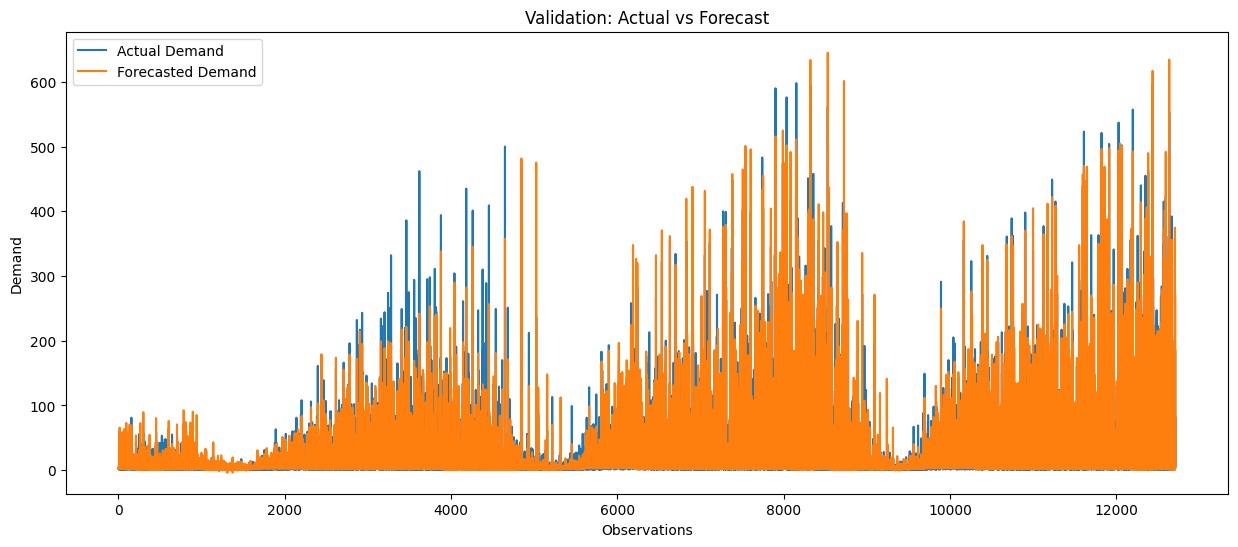

In [23]:
plt.figure(figsize=(15, 6))

plt.plot(
    y_val.values,
    label="Actual Demand"
)

plt.plot(
    val_predictions,
    label="Forecasted Demand"
)

plt.title(
    "Validation: Actual vs Forecast"
)

plt.xlabel("Observations")

plt.ylabel("Demand")

plt.legend()

plt.show()

## Observations

1. **The baseline XGBoost model captures the overall demand pattern reasonably well.**
   - Forecasted demand generally follows the upward and downward movements observed in the actual demand series.

2. **The model is able to learn recurring demand cycles present in the validation data.**
   - Predicted values reflect the major temporal patterns and seasonality observed across the validation period.

3. **Prediction errors are more noticeable during high-demand periods.**
   - Several demand spikes are either underestimated or overestimated, indicating that the baseline model struggles to fully capture extreme demand fluctuations.

4. **Model performance is relatively stable during low and moderate demand intervals.**
   - Forecasted values remain close to actual demand when demand levels are less volatile.

5. **No major systematic bias is observed.**
   - The model does not consistently overpredict or underpredict demand throughout the validation period.

6. **There is potential for further improvement through hyperparameter tuning.**
   - Refining model parameters may help reduce forecasting errors, particularly during peak demand periods.

---

## Conclusion

The baseline XGBoost model successfully learns the general hourly taxi demand patterns and captures most of the underlying demand trends in the validation dataset. While forecast accuracy decreases during extreme demand spikes, the model provides a solid starting point for further optimization. The results indicate that additional hyperparameter tuning and feature refinement may improve forecasting performance and reduce prediction errors.

---

# Step 15:Hyperparameter Comparison

## Purpose

Evaluate different model configurations to identify the best-performing XGBoost model.

## Description

Model performance can vary depending on tree depth and learning complexity.

Several configurations are evaluated using validation RMSE.

## Expected Outcome

The configuration with the lowest validation RMSE is selected.

In [42]:
# # Test different max_depth values and select the one with the lowest validation RMSE
results = []

for depth in [4, 6, 8]:

    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=depth,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    preds = model.predict(
        X_val
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_val,
            preds
        )
    )

    results.append(
        [depth, rmse]
    )

comparison = pd.DataFrame(
    results,
    columns=[
        "Max_Depth",
        "RMSE"
    ]
)

comparison.sort_values(
    "RMSE"
)

,Max_Depth,RMSE
1,6,12.661941
2,8,12.718421
0,4,13.250911


# Step 16:Select Best Model

## Purpose

Identify the best-performing XGBoost configuration based on validation RMSE.

## Description

The model with the lowest validation RMSE is selected as the final forecasting model.

A lower RMSE indicates better forecasting performance and fewer prediction errors.

## Expected Outcome

The optimal hyperparameter configuration is identified.

In [25]:
best_model = (
    comparison
    .sort_values("RMSE")
    .iloc[0]
)

best_model

Max_Depth     6.000000
RMSE         12.661941
Name: 1, dtype: float64

# Step 17:Retrain Final Model

## Purpose

Train the best-performing XGBoost model using both training and validation data.

## Description

Once the optimal configuration has been identified, the model is retrained using all available development data.

This allows the model to learn from a larger amount of historical information before final testing.

## Expected Outcome

A final optimized XGBoost model is created.

In [28]:
X_train_final = pd.concat(
    [X_train, X_val]
)

y_train_final = pd.concat(
    [y_train, y_val]
)

final_model_2 = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=int(best_model["Max_Depth"]),
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

final_model_2.fit(
    X_train_final,
    y_train_final
)

print("Final model 2 trained successfully.")

Final model 2 trained successfully.


# Step 18:Test Forecast

## Purpose

Generate demand forecasts for completely unseen data.

## Description

The test dataset represents future observations that were never used during training or model tuning.

Forecasting performance on this dataset provides the most realistic estimate of model performance.

## Expected Outcome

Predicted demand values are generated for the test period.

In [45]:
test_predictions = final_model_2.predict(
    X_test
)
print("Prediction:", test_predictions[:5])
print("Test forecasts generated successfully.")

Prediction: [  2.758857  119.055046    1.5271946   1.6677957  13.890918 ]
Test forecasts generated successfully.


# Step 19:Final Evaluation

## Purpose

Measure forecasting accuracy on completely unseen data.

## Description

Performance metrics are calculated using the test dataset.

These results represent the final forecasting capability of the model.

## Metrics

- MAE
- RMSE
- R² Score

## Expected Outcome

Reliable estimation of real-world forecasting performance.

In [30]:
mae = mean_absolute_error(
    y_test,
    test_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_predictions
    )
)

r2 = r2_score(
    y_test,
    test_predictions
)

print("Test MAE :", round(mae, 2))
print("Test RMSE :", round(rmse, 2))
print("Test R² :", round(r2, 4))

Test MAE : 6.04
Test RMSE : 13.9
Test R² : 0.9626


# Step 20:Actual vs Forecast Comparison

## Purpose

Visualize how closely the model forecasts match actual demand values.

## Description

A visual comparison helps evaluate whether the model captures demand fluctuations, peaks, and low-demand periods.

## Expected Outcome

Forecasted values should closely follow actual demand patterns.

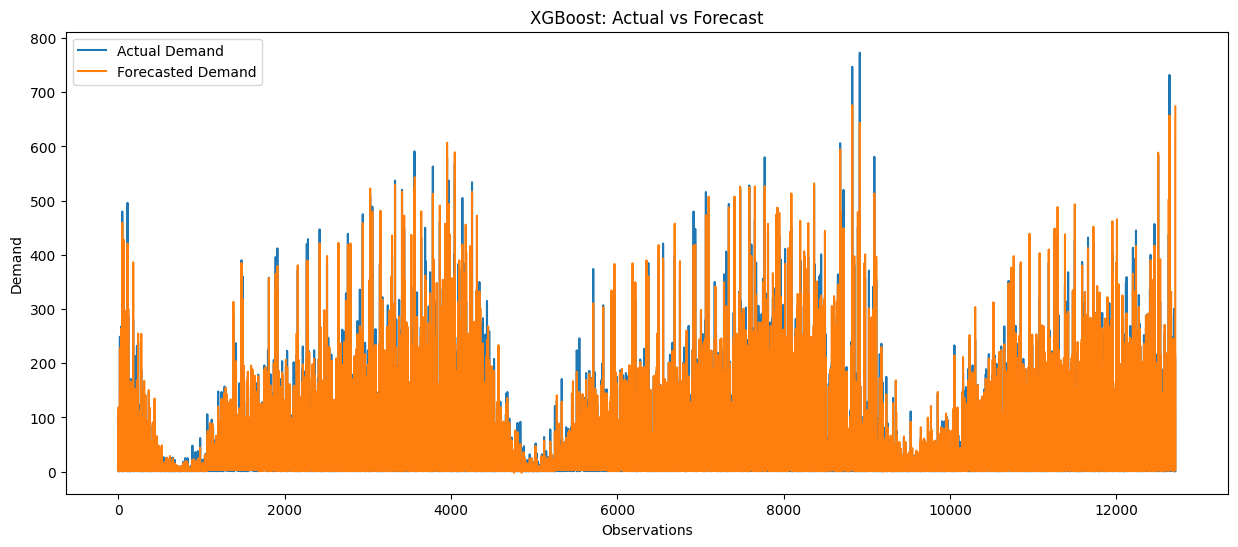

In [31]:
plt.figure(figsize=(15,6))

plt.plot(
    y_test.values,
    label="Actual Demand"
)

plt.plot(
    test_predictions,
    label="Forecasted Demand"
)

plt.title(
    "XGBoost: Actual vs Forecast"
)

plt.xlabel("Observations")

plt.ylabel("Demand")

plt.legend()

plt.show()

## Observations

1. **The tuned XGBoost model closely follows the overall demand pattern throughout the validation period.**
   - Forecasted demand remains aligned with actual demand across most observations.

2. **The model successfully captures recurring demand cycles.**
   - Repeated peaks and troughs are reproduced, indicating that the model has learned the underlying temporal structure of the data.

3. **Forecast accuracy is strongest during stable demand periods.**
   - Predicted values closely match actual demand when demand fluctuations are moderate.

4. **Some prediction errors remain during extreme demand spikes.**
   - The model occasionally underestimates or overestimates sudden increases in demand, which is common in highly volatile time-series data.

5. **No significant systematic overprediction or underprediction is observed.**
   - Forecasts remain centered around actual demand levels across the validation period.

6. **The model demonstrates improved pattern recognition compared to the baseline model.**
   - Forecasts capture demand fluctuations more consistently, suggesting that feature engineering and hyperparameter tuning have improved model performance.

---

## Conclusion

The tuned XGBoost model effectively captures both short-term demand fluctuations and recurring seasonal patterns in the validation dataset. Although minor deviations are present during extreme demand events, the forecast closely tracks actual demand across most observations. The results indicate that the model has learned meaningful temporal relationships and provides reliable hourly taxi demand forecasts.

---

# Step 21:Feature Importance Analysis

## Purpose

Identify which features contribute most to forecasting performance.

## Description

XGBoost assigns an importance score to each feature based on its contribution to reducing prediction error.

This analysis helps explain the model's forecasting behavior.

## Expected Outcome

The most influential demand predictors are identified.

In [32]:
importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": final_model_2.feature_importances_
})

importance = (
    importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

importance.head(15)

,Feature,Importance
7,lag_1,0.637447
8,lag_24,0.203214
9,lag_168,0.081253
10,rolling_mean_24,0.019149
2,day_of_week,0.012246
5,week,0.011314
1,hour_of_day,0.010949
0,PULocationID,0.006517
6,is_weekend,0.006316
11,rolling_mean_168,0.005998


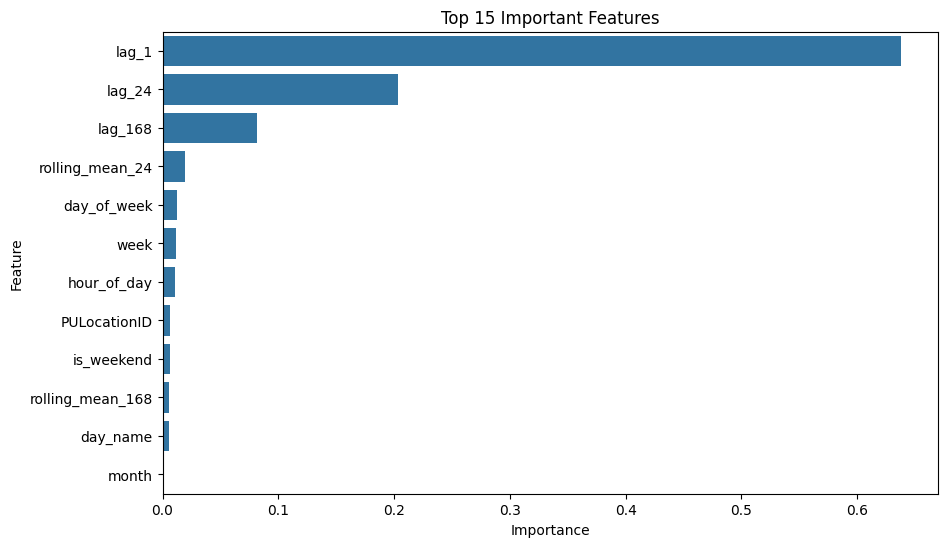

In [33]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Important Features"
)

plt.show()

## Observations

1. **Lag-based features are the strongest predictors of taxi demand.**
   - `lag_1`, `lag_24`, and `lag_168` contribute the highest importance scores, indicating that historical demand patterns play a dominant role in forecasting future demand.

2. **Recent demand has the greatest influence on predictions.**
   - `lag_1` is the most important feature, suggesting that demand from the previous hour is highly informative for forecasting the next hour's demand.

3. **Daily and weekly seasonality are effectively captured.**
   - The strong importance of `lag_24` and `lag_168` indicates that the model leverages recurring daily and weekly demand patterns.

4. **Rolling statistical features provide additional predictive value.**
   - Features such as `rolling_mean_24` contribute to model performance by capturing short-term demand trends and smoothing demand fluctuations.

5. **Calendar-based features have relatively lower importance.**
   - Variables such as `hour_of_day`, `week`, `is_weekend`, and `month` contribute less compared to lag-based features, suggesting that historical demand contains more predictive information than calendar attributes alone.

6. **Demand forecasting is primarily driven by temporal dependencies.**
   - The feature importance distribution confirms that past demand behavior is the key factor influencing future demand predictions.

---

## Conclusion

The feature importance analysis shows that the XGBoost model relies heavily on lag-based features, particularly hourly, daily, and weekly demand history. This indicates that taxi demand exhibits strong temporal dependence and recurring seasonal patterns. While rolling statistics and calendar-based variables provide supplementary information, historical demand remains the primary driver of forecast accuracy.

---

# Step 22:Residual Analysis

## Purpose

Analyze forecasting errors generated by the model.

## Description

Residuals represent the difference between actual demand and predicted demand.

A well-performing model should produce residuals centered around zero.

## Expected Outcome

Residuals should appear approximately random with no major bias.

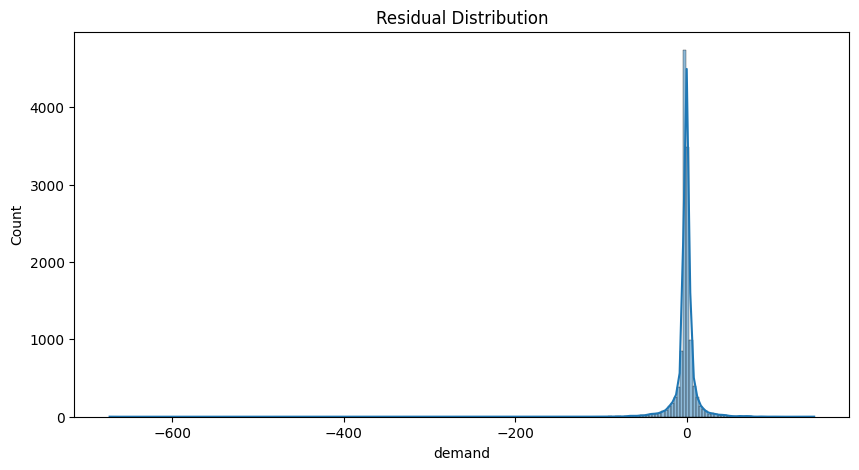

In [34]:
residuals = (
    y_test
    - test_predictions
)

plt.figure(figsize=(10,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title(
    "Residual Distribution"
)

plt.show()

## Observations

1. **Residuals are highly concentrated around zero.**
   - The distribution shows a sharp peak near zero, indicating that most forecast errors are small.

2. **The model does not exhibit significant overall bias.**
   - Since residuals are centered close to zero, the model is not consistently overpredicting or underpredicting demand.

3. **Most predictions are reasonably accurate.**
   - The high density around zero suggests that forecasted demand is generally close to actual demand for the majority of observations.

4. **A small number of large errors are present.**
   - The long tails on both sides of the distribution indicate occasional instances where the model significantly overestimates or underestimates demand.

5. **Error distribution is approximately symmetric.**
   - Positive and negative residuals appear relatively balanced, suggesting that prediction errors occur in both directions rather than being systematically biased.

6. **Extreme demand periods likely contribute to outliers.**
   - Large residual values are most likely associated with sudden demand spikes or unusual demand fluctuations that are difficult for the model to predict accurately.

---

## Conclusion

The residual distribution indicates that the XGBoost model produces generally accurate forecasts, with most prediction errors concentrated near zero. The absence of a strong bias suggests balanced forecasting performance, while the presence of a few large residuals highlights challenges in predicting extreme demand events. Overall, the residual analysis confirms that the model captures the underlying demand patterns effectively and generates stable forecasts across most observations.

---

# Step 23:Forecast Error Summary

## Purpose

Summarize the distribution of forecasting errors.

## Description

Statistical properties of forecast errors provide insight into model stability and prediction bias.

## Expected Outcome

Errors should be reasonably centered around zero with limited extreme deviations.

In [35]:
forecast_errors = (
    y_test
    - test_predictions
)

forecast_errors.describe()

count    12712.000000
mean        -1.015752
std         13.863030
min       -672.879211
25%         -2.453252
50%         -0.718797
75%          1.615667
max        148.629379
Name: demand, dtype: float64

# Step 24:Save Trained Model

## Purpose

Persist the final XGBoost model for future forecasting and deployment.

## Expected Outcome

The trained model is stored successfully and can be reused without retraining.

In [ ]:
import joblib

joblib.dump(
    final_model_2,
    "/home/ed/Desktop/NYC_Taxi_Demand_Forecasting/Yellow_Dataset/models/xgboost_model.pkl"
)

print("XGBoost model saved successfully.")

XGBoost model saved successfully.
